# IT106L PREFINAL EXAMINATION

# Step 1: Formulate Research Question

# 1. Reasearch Question



Research Question: How do the distance of the delivery, the food preparation time, and the courier's experience level affect the total delivery time for food orders?   Identification of Variables:Dependent Variable (y): Delivery_Time_min (The target continuous value we want to predict).  Independent Variables (X): Distance_km, Preparation_Time_min, and Courier_Experience_yrs (The numerical predictors that likely influence delivery duration).  

Objective:
The objective of this prediction is to build a Multiple Linear Regression model capable of accurately estimating the total delivery time. This is essential for setting proper customer expectations, optimizing logistics, and improving overall customer satisfaction in the food delivery platform.

# 2. Data Validation and Cleaning




In this step, I loaded the `Food_Delivery_Times.csv` dataset and checked its structure, data types, missing values, and duplicate records. This step is important because the model needs clean and complete data before training.

The dataset contains both numerical and categorical columns. For this Multiple Linear Regression model, I selected only the numerical columns needed for prediction: `Distance_km`, `Preparation_Time_min`, `Courier_Experience_yrs`, and `Delivery_Time_min`.

Other columns such as `Order_ID`, `Weather`, `Traffic_Level`, `Time_of_Day`, and `Vehicle_Type` were not used in this basic regression model because they are either identifiers or categorical variables. These categorical variables would need encoding before they can be included in the model.

Rows with missing values in the selected columns were removed to avoid errors during model training. Duplicate records were also checked to make sure repeated data would not affect the model.

Markdown Documentation:

In [9]:

# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle

# Load the dataset
df = pd.read_csv("Food_Delivery_Times.csv")

# Inspect dataset structure and data types
print("Dataset Info:")
df.info()

# Display the first few rows
print("\nFirst 5 Rows:")
display(df.head())

# Check for missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Check for duplicate records
duplicates = df.duplicated().sum()
print(f"\nDuplicate Records: {duplicates}")

# Remove duplicate records if there are any
if duplicates > 0:
    df = df.drop_duplicates()

# Select relevant numerical columns for Multiple Linear Regression
df_cleaned = df[
    [
        "Distance_km",
        "Preparation_Time_min",
        "Courier_Experience_yrs",
        "Delivery_Time_min"
    ]
].dropna()

# Validate data consistency and ranges
print("\nSummary Statistics after Cleaning:")
display(df_cleaned.describe())

print("\nMinimum Values:")
print(df_cleaned.min())

print("\nMaximum Values:")
print(df_cleaned.max())

print("\nCleaned Dataset Shape:")
print(df_cleaned.shape)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 70.4 KB

First 5 Rows:


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68



Missing Values per Column:
Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

Duplicate Records: 0

Summary Statistics after Cleaning:


,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,970.000000,970.000000,970.000000,970.000000
mean,10.052897,17.007216,4.579381,56.743299
std,5.688677,7.202149,2.914394,22.071352
min,0.590000,5.000000,0.000000,8.000000
25%,5.130000,11.000000,2.000000,41.000000
50%,10.190000,17.000000,5.000000,56.000000
75%,14.995000,23.000000,7.000000,71.000000
max,19.990000,29.000000,9.000000,153.000000



Minimum Values:
Distance_km               0.59
Preparation_Time_min      5.00
Courier_Experience_yrs    0.00
Delivery_Time_min         8.00
dtype: float64

Maximum Values:
Distance_km                19.99
Preparation_Time_min       29.00
Courier_Experience_yrs      9.00
Delivery_Time_min         153.00
dtype: float64

Cleaned Dataset Shape:
(970, 4)



# Step 3. Exploratory Data Analysis (EDA)




Markdown Documentation:



In this step, I used two visual dashboards to understand the relationship between the selected independent variables and the delivery time.

The first dashboard shows the scatterplots of `Distance_km`, `Preparation_Time_min`, and `Courier_Experience_yrs` against `Delivery_Time_min`. These visualizations help identify the trend and direction of each variable. Distance and preparation time are expected to have a positive relationship with delivery time because longer distances and longer preparation usually increase the total delivery duration. Courier experience may show a negative relationship because more experienced couriers may deliver faster.

The second dashboard is the correlation heatmap. It shows how strongly the variables are related to each other. This helps assess whether the selected variables are suitable for Multiple Linear Regression.

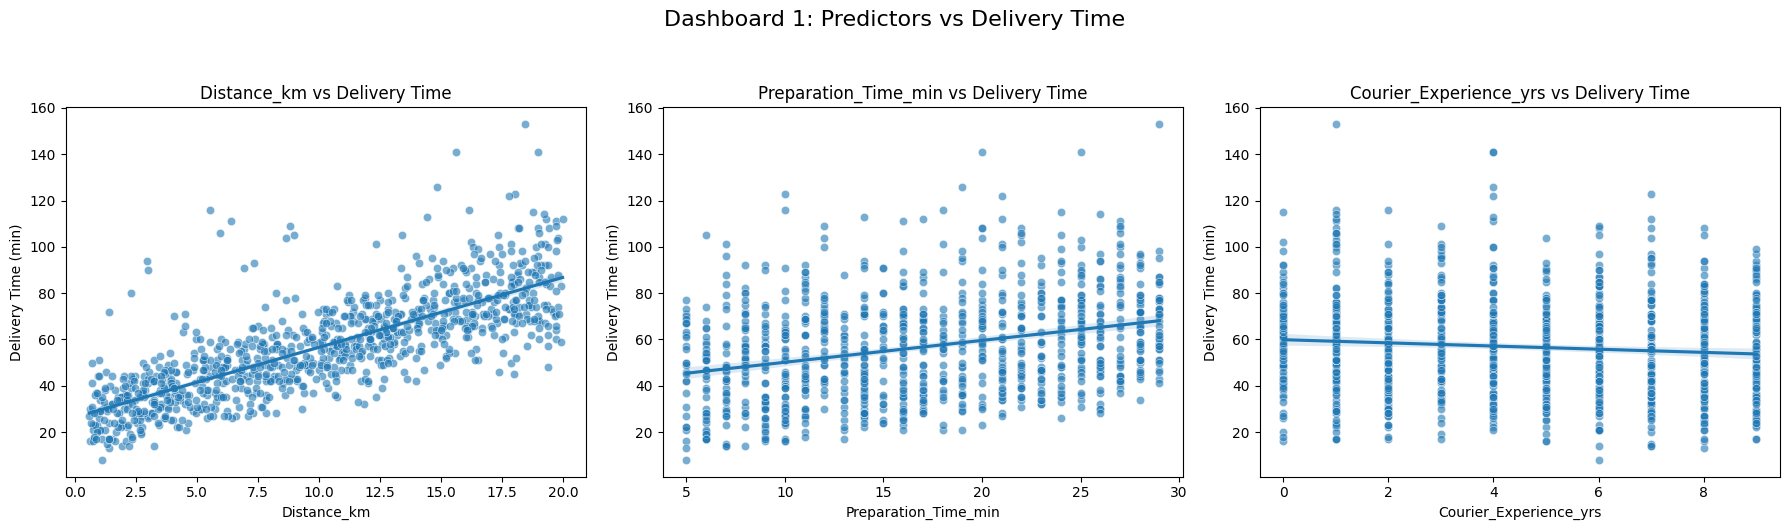

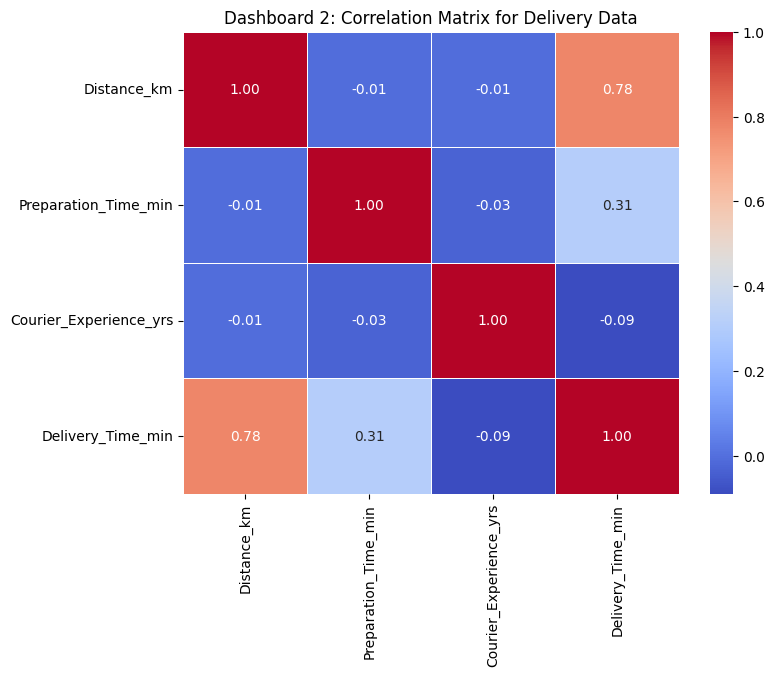

In [11]:

# Dashboard 1: Scatter Plots of Predictors vs Delivery Time
plt.figure(figsize=(18, 5))

features = ["Distance_km","Preparation_Time_min","Courier_Experience_yrs"]

for i, col in enumerate(features):
    plt.subplot(1, 3, i + 1)
    
    sns.scatterplot(
        x=df_cleaned[col],
        y=df_cleaned["Delivery_Time_min"],
        alpha=0.6
    )
    
    sns.regplot(
        x=df_cleaned[col],
        y=df_cleaned["Delivery_Time_min"],
        scatter=False
    )
    
    plt.title(f"{col} vs Delivery Time")
    plt.xlabel(col)
    plt.ylabel("Delivery Time (min)")

plt.suptitle("Dashboard 1: Predictors vs Delivery Time", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()
# Dashboard 2: Correlation Matrix Heatmap
plt.figure(figsize=(8, 6))

correlation_matrix = df_cleaned.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Dashboard 2: Correlation Matrix for Delivery Data")
plt.show()

# Step 4: Model Training



Markdown Documentation:


In this step, I defined the independent variables and the dependent variable. The independent variables are `Distance_km`, `Preparation_Time_min`, and `Courier_Experience_yrs`, while the dependent variable is `Delivery_Time_min`.

The dataset was split into training and testing sets. The training set was used to train the Multiple Linear Regression model, while the testing set was used to evaluate how well the model performs on new data.

After training the model, the intercept and coefficients were displayed. The intercept represents the estimated delivery time when all independent variables are zero. The coefficients show how much the delivery time changes when each independent variable increases by one unit.

In [14]:

# Define X and y
X = df_cleaned[["Distance_km","Preparation_Time_min","Courier_Experience_yrs"]]

y = df_cleaned["Delivery_Time_min"]

# Perform train-test split: 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train the Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Identify intercept and coefficients
print(f"Intercept: {model.intercept_:.2f}")

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nFeature Coefficients:")
display(coefficients)

Intercept: 12.47

Feature Coefficients:


,Feature,Coefficient
0,Distance_km,3.01869
1,Preparation_Time_min,0.97010
2,Courier_Experience_yrs,-0.56751



# Step 5: Performance Evaluation



Markdown Documentation:


In this step, I used the trained model to generate predictions using the test data. The predicted delivery times were compared with the actual delivery times to evaluate the performance of the model.

The Mean Absolute Error shows the average difference between the actual and predicted delivery time in minutes. The Mean Squared Error gives more penalty to larger errors. The Root Mean Squared Error also shows the prediction error in minutes, making it easier to understand because it uses the same unit as the target variable.

The R-squared score shows how much of the variation in delivery time is explained by the selected variables. The Actual vs Predicted plot shows how close the predictions are to the actual values. If the points are close to the diagonal line, it means the model performs well. If the points are far from the line, it means the model has larger prediction errors.




Mean Absolute Error (MAE): 7.29 minutes
Mean Squared Error (MSE): 116.55
Root Mean Squared Error (RMSE): 10.80 minutes
R-squared (R2): 0.7687


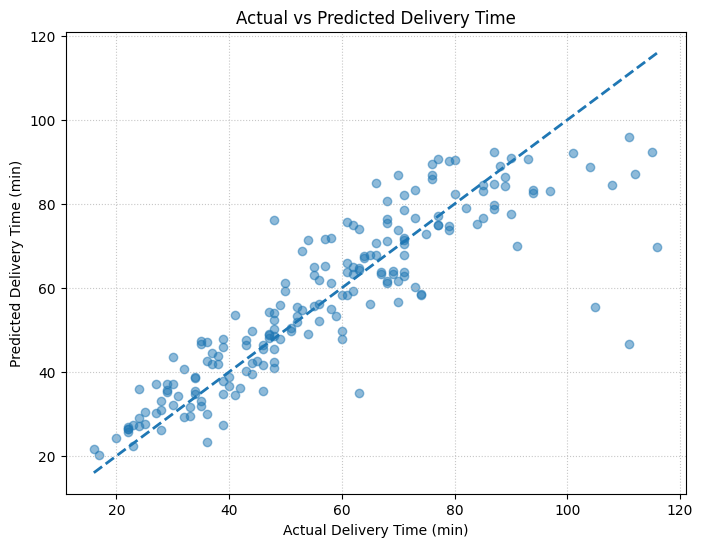

Model successfully saved as ITC106L_PREFINAL_model.pkl


In [13]:
# Generate predictions
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display results
print(f"Mean Absolute Error (MAE): {mae:.2f} minutes")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} minutes")
print(f"R-squared (R2): {r2:.4f}")
# Visualization: Actual vs Predicted Delivery Time
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Delivery Time (min)")
plt.ylabel("Predicted Delivery Time (min)")
plt.title("Actual vs Predicted Delivery Time")
plt.grid(True, linestyle=":", alpha=0.7)

plt.show()
# Export the trained model
with open("ITC106L_PREFINAL_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model successfully saved as ITC106L_PREFINAL_model.pkl")

# 6: Reflection and Analysis



Markdown Documentation:

The selected variables can help explain changes in delivery time based on the EDA results and the coefficients of the regression model. Distance and preparation time show a positive relationship with delivery time. This means that when the delivery distance becomes longer or the food preparation takes more time, the total delivery time also tends to increase. Courier experience may have a negative relationship because couriers with more experience may be able to complete deliveries faster.

One limitation of the model is that it only uses numerical data. Other important factors like weather, traffic level, time of day, and vehicle type were not included because they are categorical variables and need to be converted first before they can be used in the model. Because of this, the model may not capture all the real-life factors that affect delivery time.

Based on the EDA and the model coefficients, the variable that contributes the most to delivery time is usually the one with the strongest relationship and the largest meaningful coefficient. In this dataset, `Distance_km` is expected to be one of the strongest predictors because longer distances naturally require more travel time.

If the strongest predictor is removed, the model will likely become less accurate. The R-squared value may go down, while the MAE, MSE, and RMSE may increase. This means the model would make bigger errors because it lost an important variable that helps explain delivery time.

Correlation does not always mean causation. For example, preparation time may be related to delivery time because longer preparation adds to the total waiting time. However, this does not mean that preparation time directly affects how fast the courier drives. Other factors such as traffic, weather, and restaurant workload may also affect the final delivery time.